# **1. Perkenalan Dataset**


Proyek ini menggunakan dataset Telco Customer Churn. Dataset ini diambil dari Kaggle yang dapat diakses melalui : https://www.kaggle.com/datasets/blastchar/telco-customer-churn. Berikut informasi mengenai datasetnya :
- Nama Dataset : Telco Customer Churn
- Jumlah Data  : 7,043
- Jumlah Fitur : 21

# **2. Import Library**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Pada tahap ini, kita mengimpor beberapa library Python yang akan digunakan untuk melakukan analisis dan pembangunan model machine learning:


*   pandas dan numpy untuk manipulasi data.
*   sklearn.model_selection untuk membagi dataset menjadi data latih dan data uji.
*   sklearn.preprocessing untuk melakukan encoding pada fitur kategorikal dan standardisasi pada fitur numerik.
*   sklearn.tree dan sklearn.ensemble untuk membangun model Decision Tree dan Random Forest.
*   sklearn.metrics untuk evaluasi model dengan menggunakan classification report dan confusion matrix.
*   matplotlib.pyplot dan seaborn untuk visualisasi data.







# **3. Memuat Dataset**

In [ ]:
# load the dataset
url = 'https://raw.githubusercontent.com/abdlsykr/portfolio/refs/heads/main/Dicoding/Machine_Learning_Terapan/WA_Fn-UseC_-Telco-Customer-Churn.csv'
data = pd.read_csv(url)
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Pada tahap ini, kita memuat dataset yang berisi data pelanggan Telco dari URL yang disediakan. Dataset ini digunakan untuk memprediksi customer churn. Setelah dataset dimuat, kita menampilkan data untuk melihat beberapa baris pertama.

# **4. Exploratory Data Analysis (EDA)**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Metode info() digunakan untuk menampilkan informasi tentang dataset, termasuk jumlah baris, kolom, dan tipe data untuk setiap kolom. Ini membantu kita memahami struktur data secara keseluruhan.

In [ ]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

<ipython-input-4-b698680ce3b7>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)




*   Di sini, kita mengonversi kolom TotalCharges menjadi tipe data numerik menggunakan pd.to_numeric. Proses ini juga menangani data yang mungkin memiliki nilai non-numerik.
*   Selanjutnya, kita mengisi missing values pada kolom TotalCharges dengan nilai median. Pengisian dengan median dilakukan agar tidak mengubah distribusi data secara signifikan.



In [ ]:
data.drop('customerID', axis=1, inplace=True)

Pada tahap ini, kita menghapus kolom customerID karena kolom ini tidak berpengaruh pada prediksi churn dan hanya bertindak sebagai identifier unik untuk setiap pelanggan.

In [ ]:
data['SeniorCitizen'] = data['SeniorCitizen'].astype('category')

Fitur SeniorCitizen diubah menjadi tipe data kategori untuk menunjukkan bahwa ini adalah fitur kategorikal, bukan numerik. Hal ini berguna untuk model yang hanya membutuhkan fitur kategorikal untuk analisis.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

In [ ]:
data.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


Metode describe() digunakan untuk menghasilkan statistik deskriptif dari dataset, termasuk nilai mean, standar deviasi, min, max, dan kuartil. Ini memberikan gambaran umum mengenai distribusi fitur numerik.

<Axes: xlabel='tenure'>

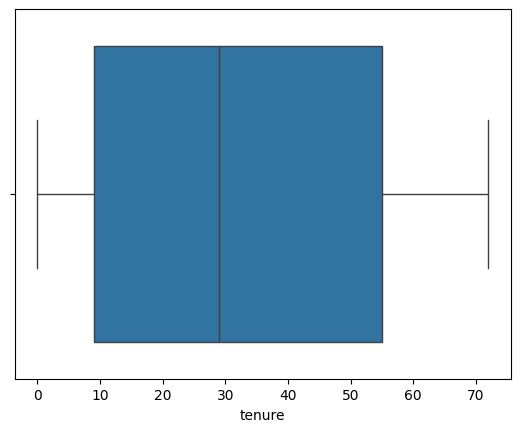

In [ ]:
sns.boxplot(x=data['tenure'])

<Axes: xlabel='MonthlyCharges'>

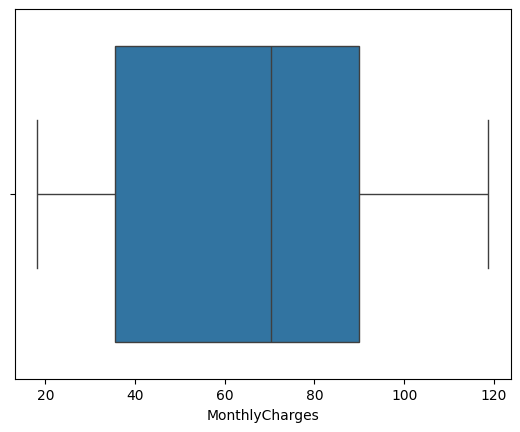

In [ ]:
sns.boxplot(x=data['MonthlyCharges'])

<Axes: xlabel='TotalCharges'>

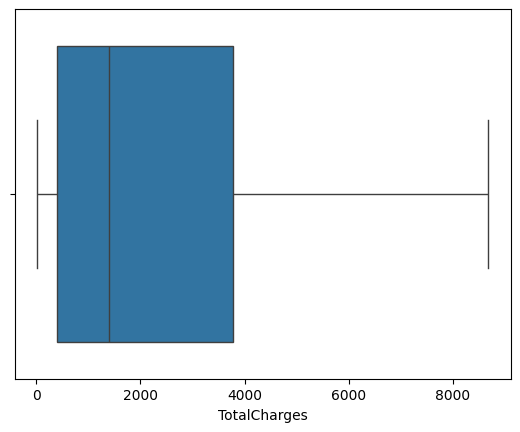

In [ ]:
sns.boxplot(x=data['TotalCharges'])

Visualisasi boxplot digunakan untuk memeriksa adanya outlier pada fitur numerik seperti tenure, MonthlyCharges, dan TotalCharges. Boxplot membantu kita melihat distribusi data dan nilai ekstrem.

In [ ]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['SeniorCitizen', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Feature: SeniorCitizen
               jumlah sampel  persentase
SeniorCitizen                           
0                       5901        83.8
1                       1142        16.2




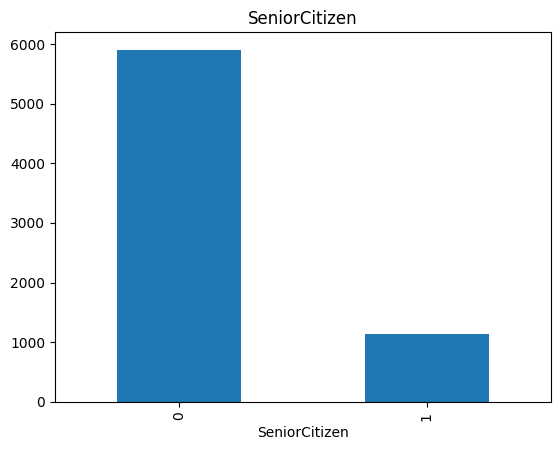

Feature: gender
        jumlah sampel  persentase
gender                           
Male             3555        50.5
Female           3488        49.5




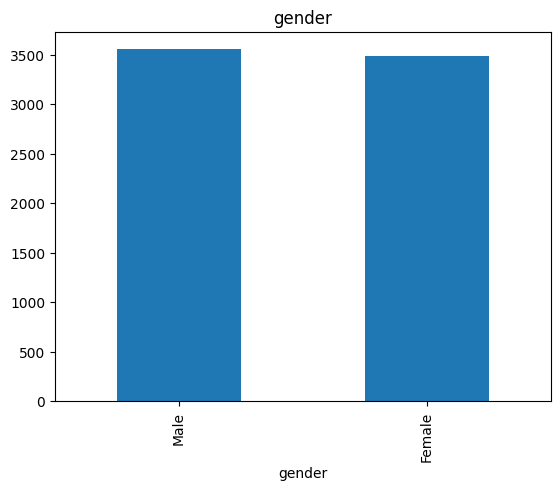

Feature: Partner
         jumlah sampel  persentase
Partner                           
No                3641        51.7
Yes               3402        48.3




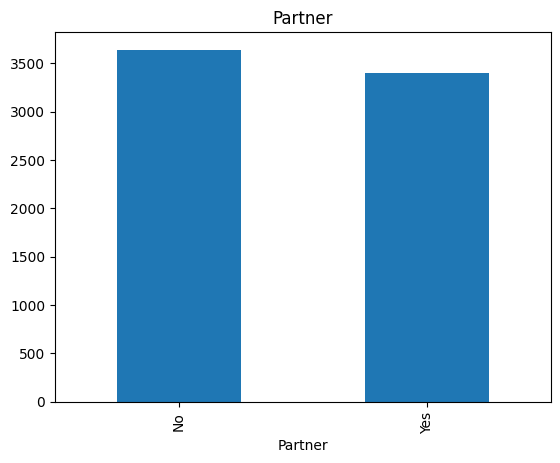

Feature: Dependents
            jumlah sampel  persentase
Dependents                           
No                   4933        70.0
Yes                  2110        30.0




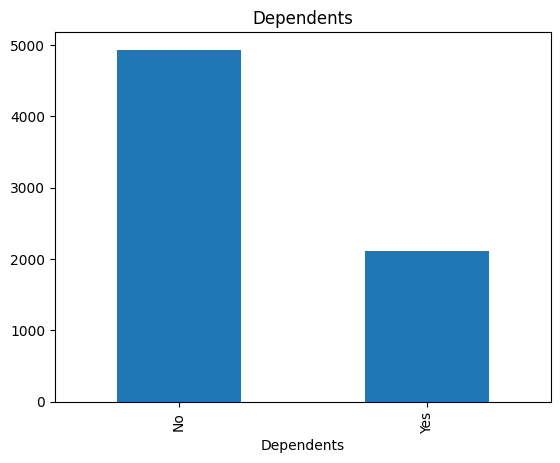

Feature: PhoneService
              jumlah sampel  persentase
PhoneService                           
Yes                    6361        90.3
No                      682         9.7




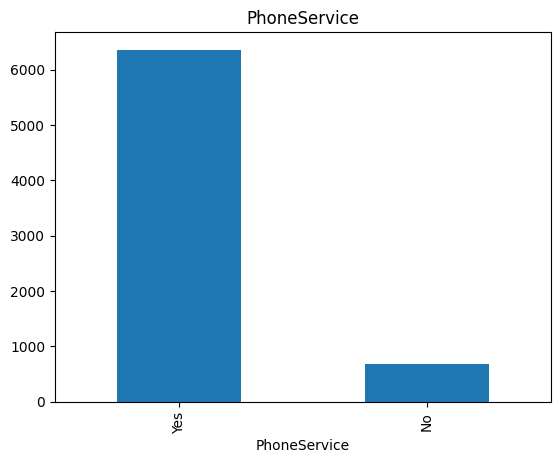

Feature: MultipleLines
                  jumlah sampel  persentase
MultipleLines                              
No                         3390        48.1
Yes                        2971        42.2
No phone service            682         9.7




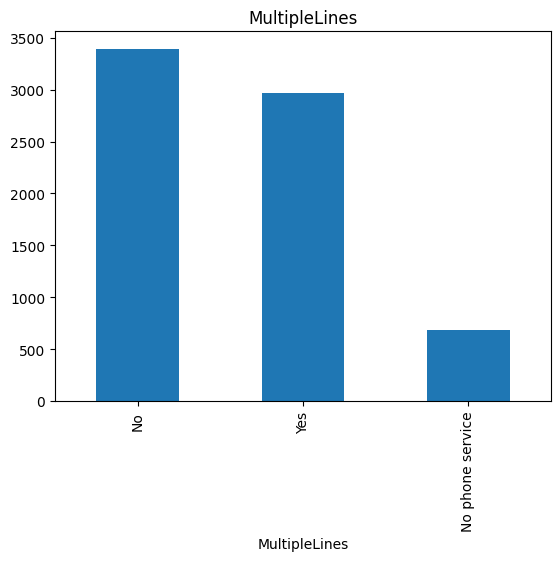

Feature: InternetService
                 jumlah sampel  persentase
InternetService                           
Fiber optic               3096        44.0
DSL                       2421        34.4
No                        1526        21.7




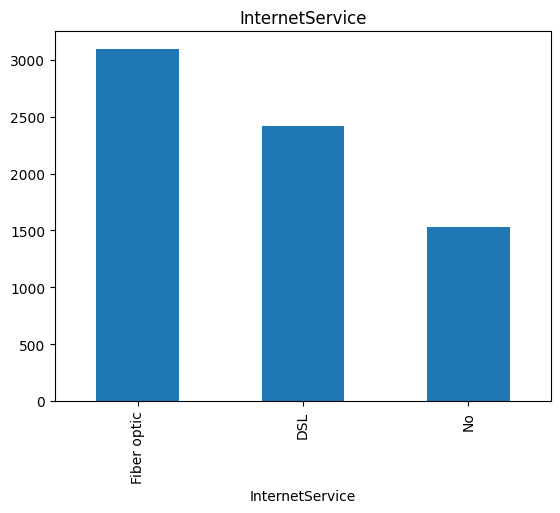

Feature: OnlineSecurity
                     jumlah sampel  persentase
OnlineSecurity                                
No                            3498        49.7
Yes                           2019        28.7
No internet service           1526        21.7




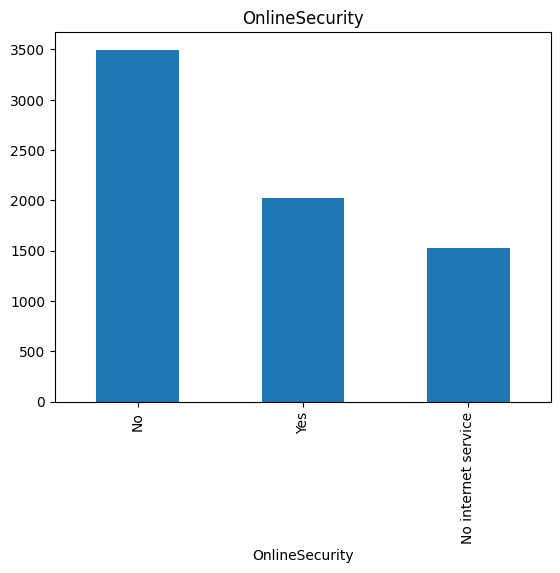

Feature: OnlineBackup
                     jumlah sampel  persentase
OnlineBackup                                  
No                            3088        43.8
Yes                           2429        34.5
No internet service           1526        21.7




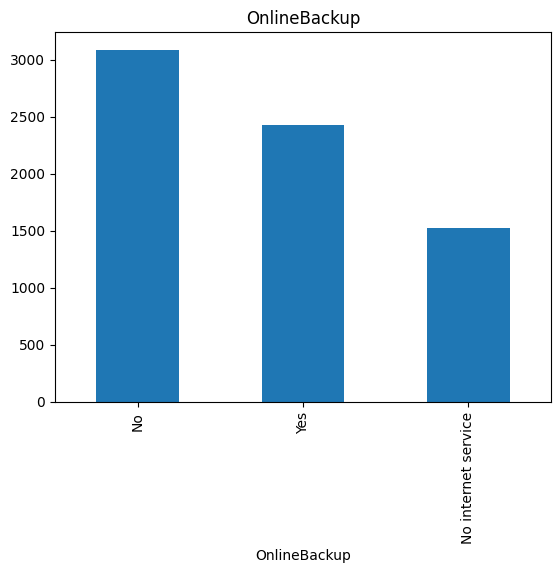

Feature: DeviceProtection
                     jumlah sampel  persentase
DeviceProtection                              
No                            3095        43.9
Yes                           2422        34.4
No internet service           1526        21.7




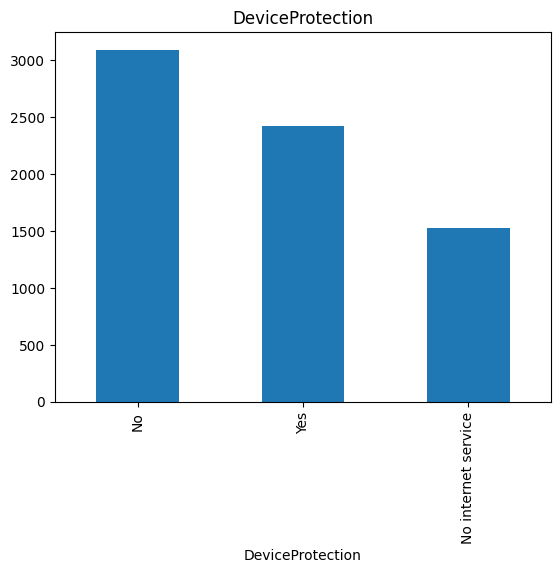

Feature: TechSupport
                     jumlah sampel  persentase
TechSupport                                   
No                            3473        49.3
Yes                           2044        29.0
No internet service           1526        21.7




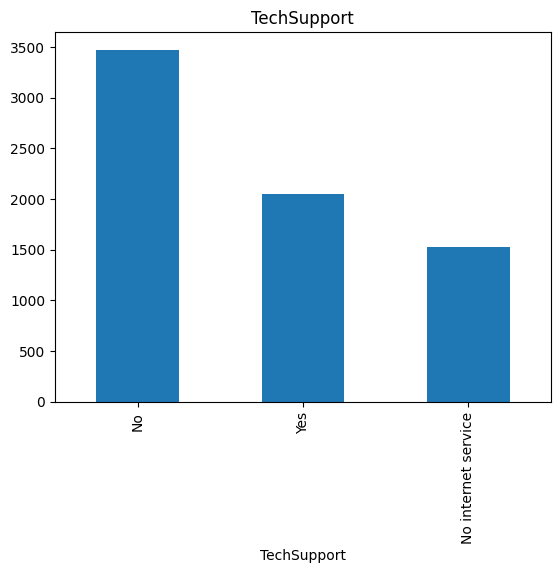

Feature: StreamingTV
                     jumlah sampel  persentase
StreamingTV                                   
No                            2810        39.9
Yes                           2707        38.4
No internet service           1526        21.7




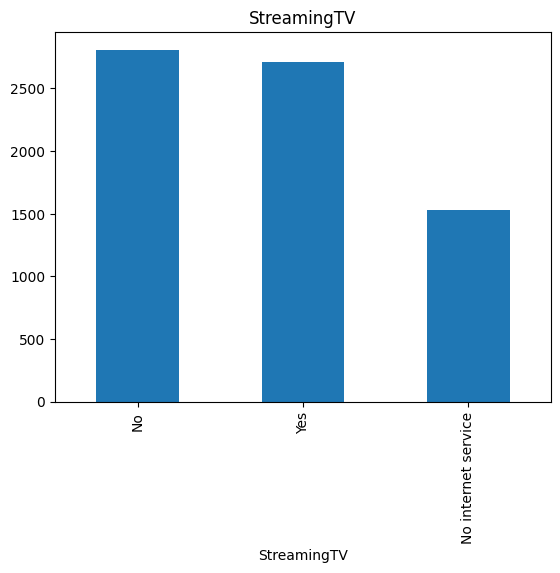

Feature: StreamingMovies
                     jumlah sampel  persentase
StreamingMovies                               
No                            2785        39.5
Yes                           2732        38.8
No internet service           1526        21.7




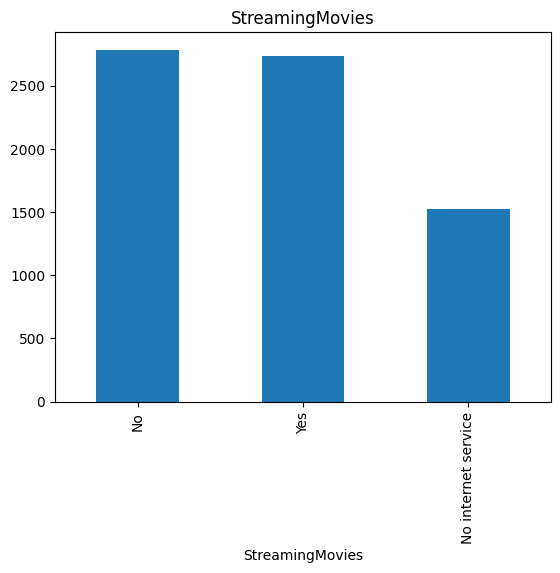

Feature: Contract
                jumlah sampel  persentase
Contract                                 
Month-to-month           3875        55.0
Two year                 1695        24.1
One year                 1473        20.9




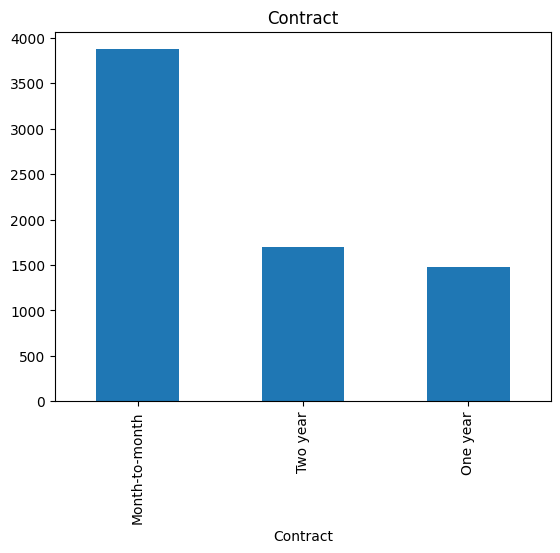

Feature: PaperlessBilling
                  jumlah sampel  persentase
PaperlessBilling                           
Yes                        4171        59.2
No                         2872        40.8




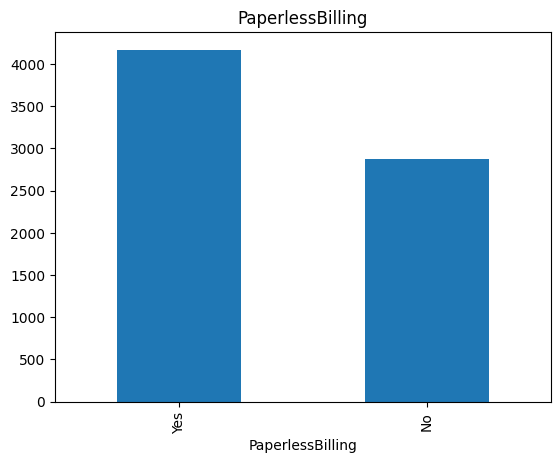

Feature: PaymentMethod
                           jumlah sampel  persentase
PaymentMethod                                       
Electronic check                    2365        33.6
Mailed check                        1612        22.9
Bank transfer (automatic)           1544        21.9
Credit card (automatic)             1522        21.6




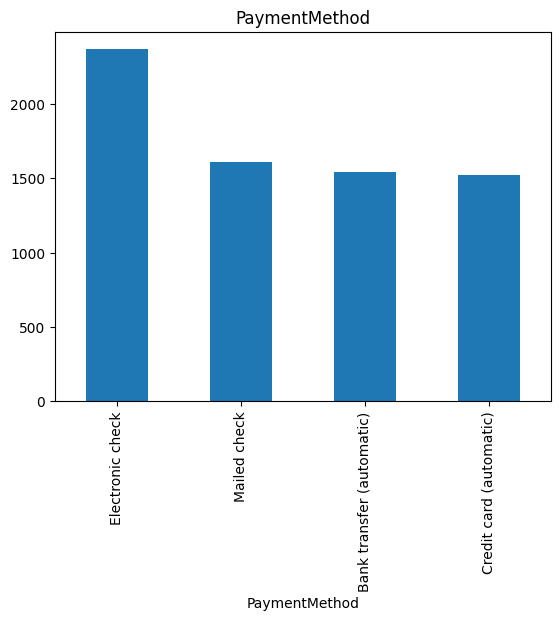

Feature: Churn
       jumlah sampel  persentase
Churn                           
No              5174        73.5
Yes             1869        26.5




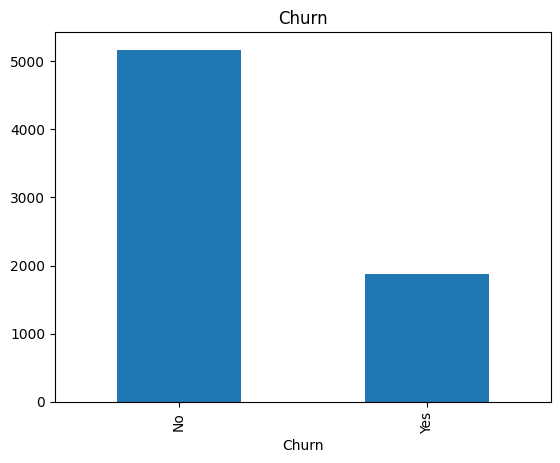

In [ ]:
for feature in categorical_features:
    count = data[feature].value_counts()
    percent = 100 * data[feature].value_counts(normalize=True)
    df = pd.DataFrame({'jumlah sampel': count, 'persentase': percent.round(1)})

    # Print the table for each feature
    print(f"Feature: {feature}")
    print(df)
    print("\n")

    # Plot bar chart for each feature
    count.plot(kind='bar', title=feature)
    plt.show()

Untuk fitur kategorikal, kita melakukan perhitungan jumlah dan persentase untuk setiap nilai unik. Hasilnya ditampilkan dalam bentuk tabel dan visualisasi grafik batang. Ini memberikan gambaran yang jelas tentang distribusi kategori untuk setiap fitur, seperti berapa banyak pelanggan yang memiliki pasangan atau menggunakan layanan internet tertentu.

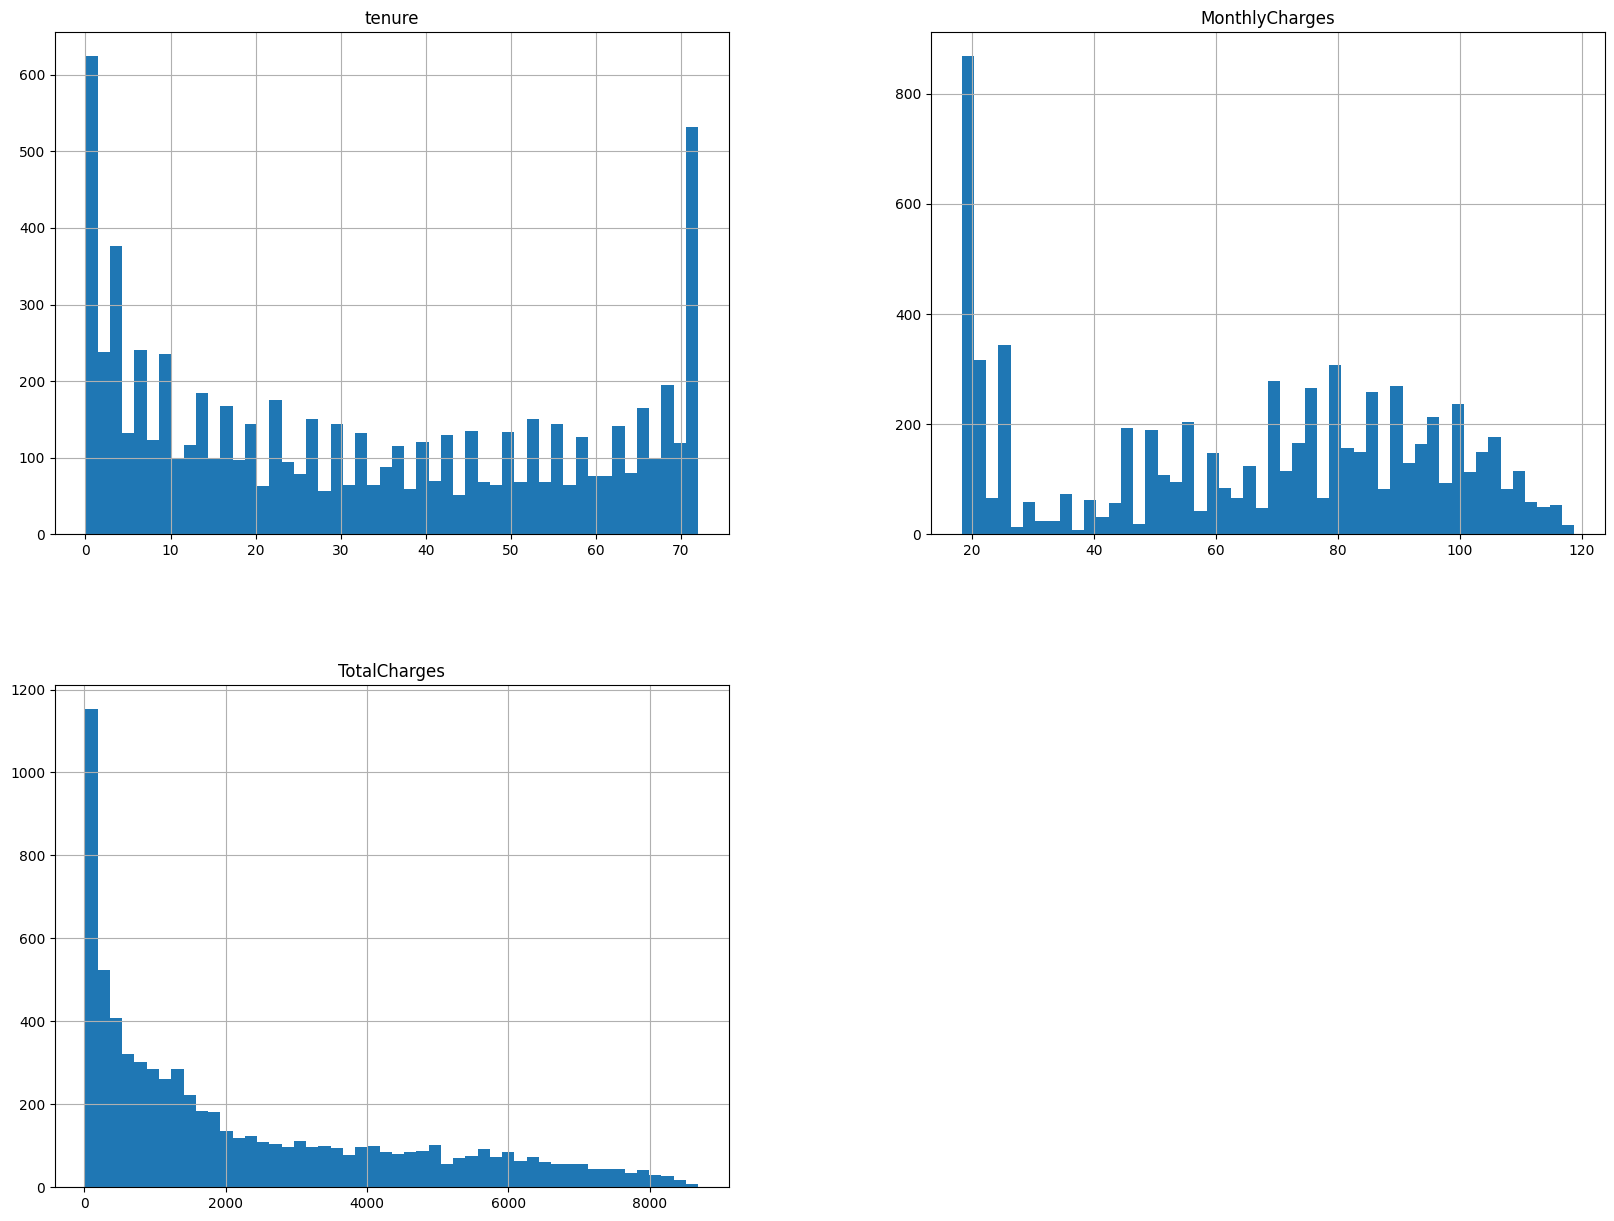

In [ ]:
data.hist(bins=50, figsize=(20,15))
plt.show()

Histogram ini memberikan gambaran tentang distribusi dari tiga fitur numerik: tenure, MonthlyCharges, dan TotalCharges. Setiap grafik memperlihatkan frekuensi data pada rentang nilai tertentu.

1.   Histogram untuk tenure:

*   tenure menunjukkan distribusi pelanggan berdasarkan masa berlangganan mereka.
*   Terlihat ada dua kelompok besar dalam data:

 - Sebagian besar pelanggan memiliki tenure rendah (lebih sedikit dari 10 bulan).
 - Ada lonjakan besar pada tenure tinggi, yang menunjukkan ada banyak pelanggan yang telah berlangganan lebih dari 60 bulan (mungkin pelanggan yang setia).

2.   Histogram untuk MonthlyCharges:

*   Biaya bulanan (MonthlyCharges) menunjukkan distribusi yang relatif merata, namun ada lonjakan besar pada nilai sekitar 20 Dollar.
*   Banyak pelanggan membayar sekitar 20 Dollar hingga 80 Dollar per bulan, dan sebagian kecil membayar lebih dari 100 Dollar.
*   Ini menunjukkan adanya berbagai pilihan paket harga dan variasi biaya bulanan untuk pelanggan.

3.   Histogram untuk MonthlyCharges:

*   TotalCharges menunjukkan rentang nilai yang lebih besar, dengan sebagian besar pelanggan membayar di bawah 2000.
*   Terdapat outlier pada sisi kanan, yang menunjukkan beberapa pelanggan dengan total pembayaran yang jauh lebih tinggi dibandingkan dengan kebanyakan pelanggan lainnya. Boxplot ini menunjukkan distribusi yang lebih tersebar.








<ipython-input-15-ba8c9e3e0110>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y="TotalCharges", kind="bar", dodge=False, height = 4, aspect = 3,  data=data, palette="Set3")
<ipython-input-15-ba8c9e3e0110>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y="TotalCharges", kind="bar", dodge=False, height = 4, aspect = 3,  data=data, palette="Set3")
<ipython-input-15-ba8c9e3e0110>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, y="TotalCharges", kind="bar", dodge=False, height = 4, aspect = 3,  data=data, palette="Set3"

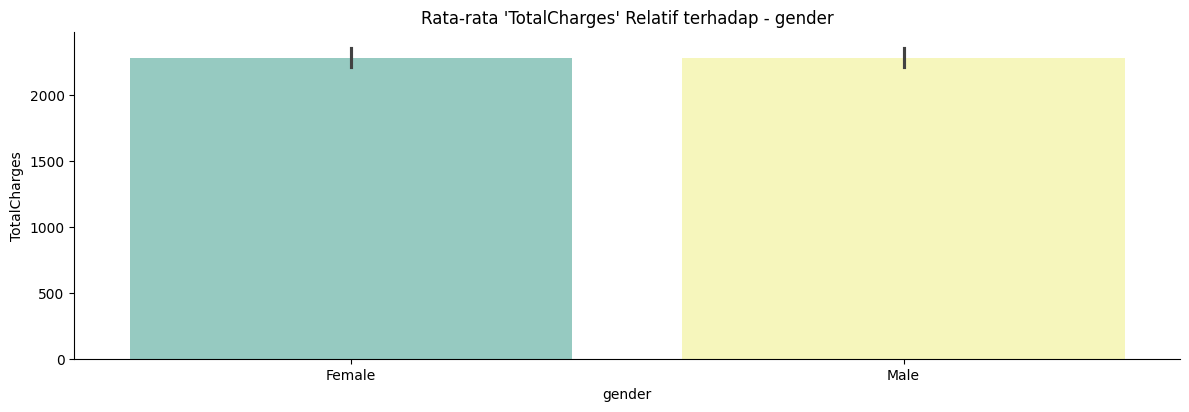

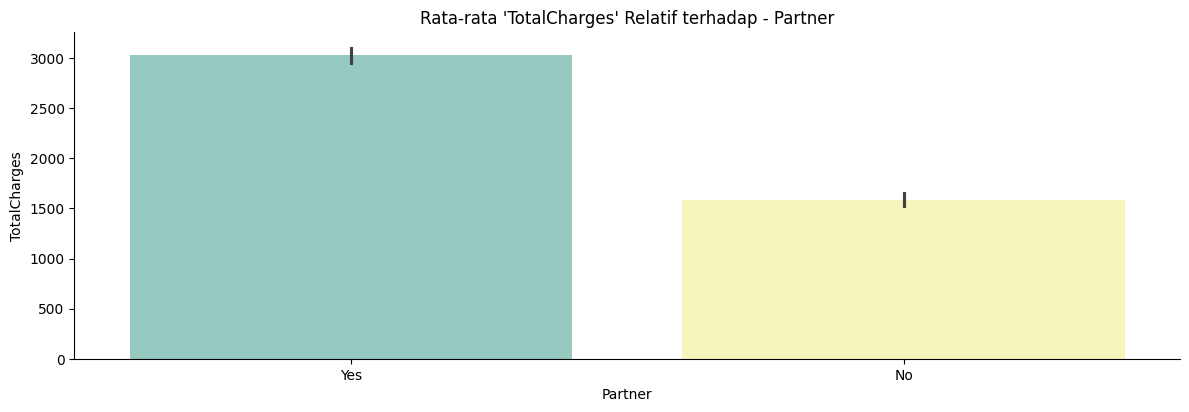

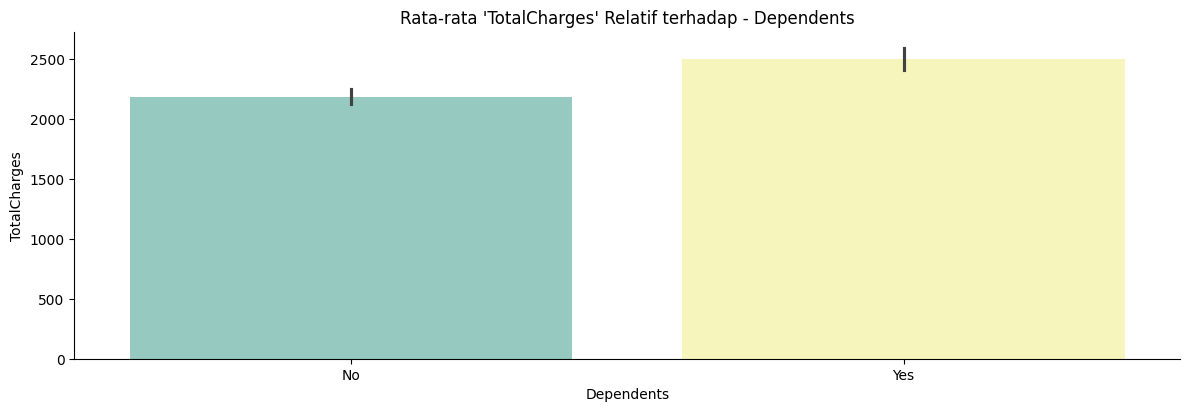

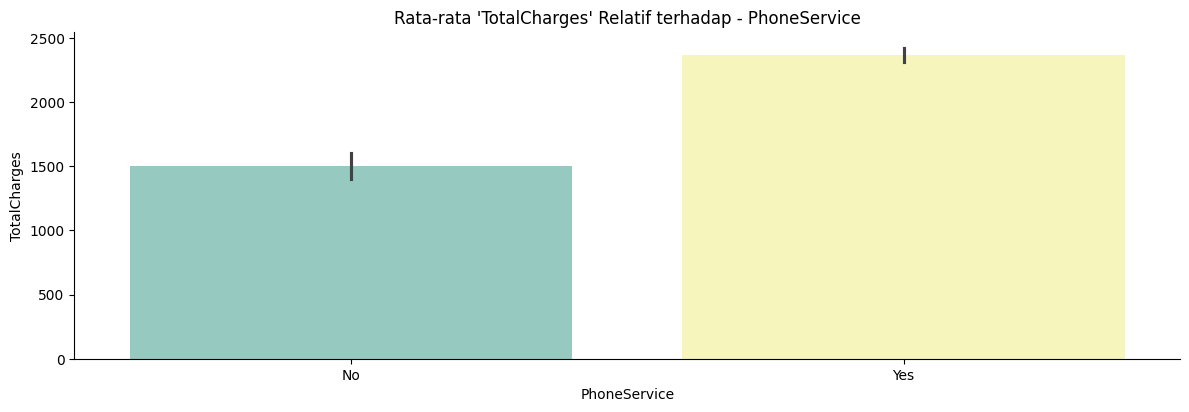

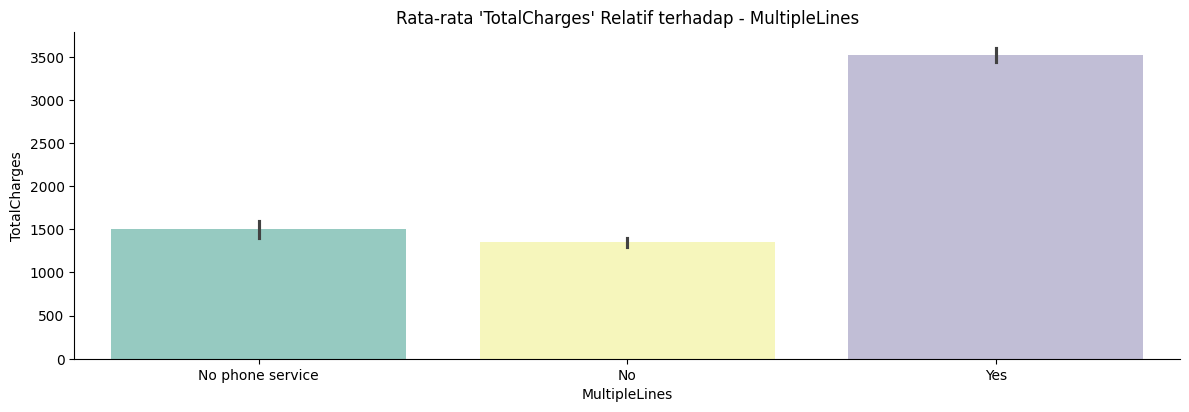

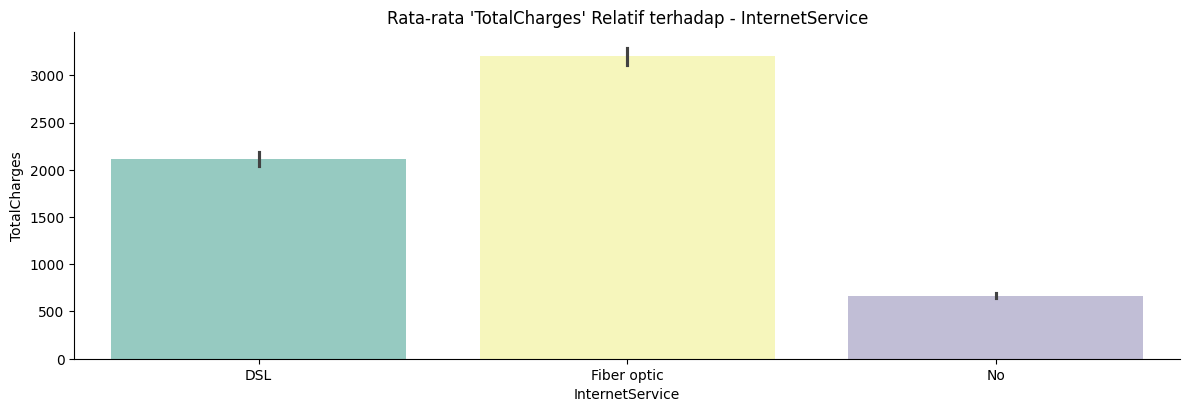

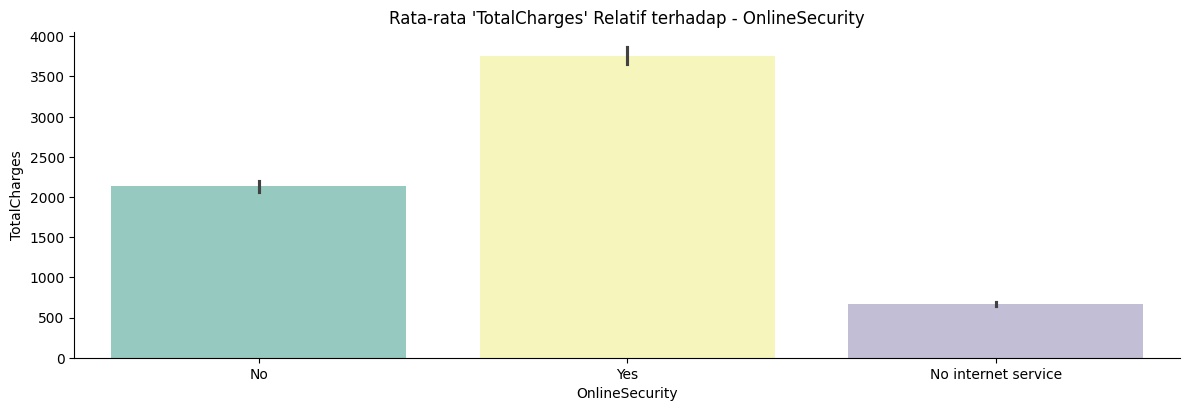

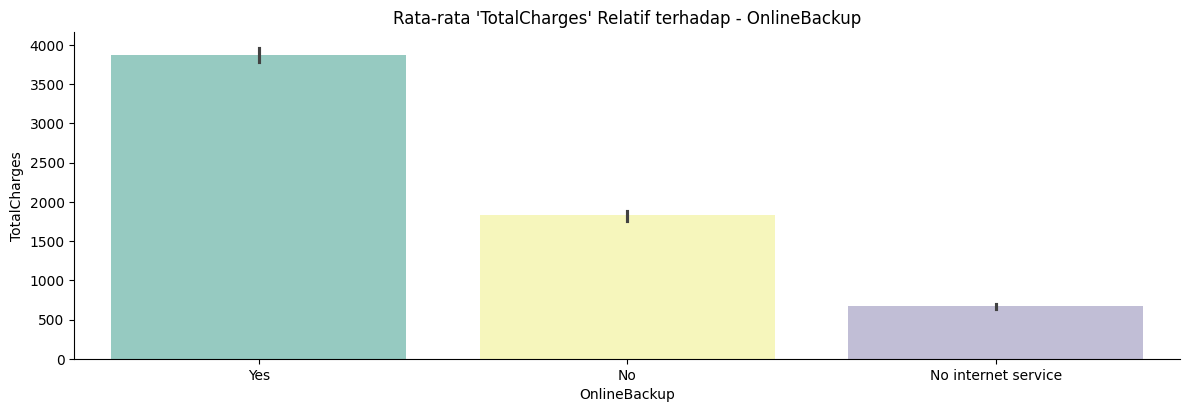

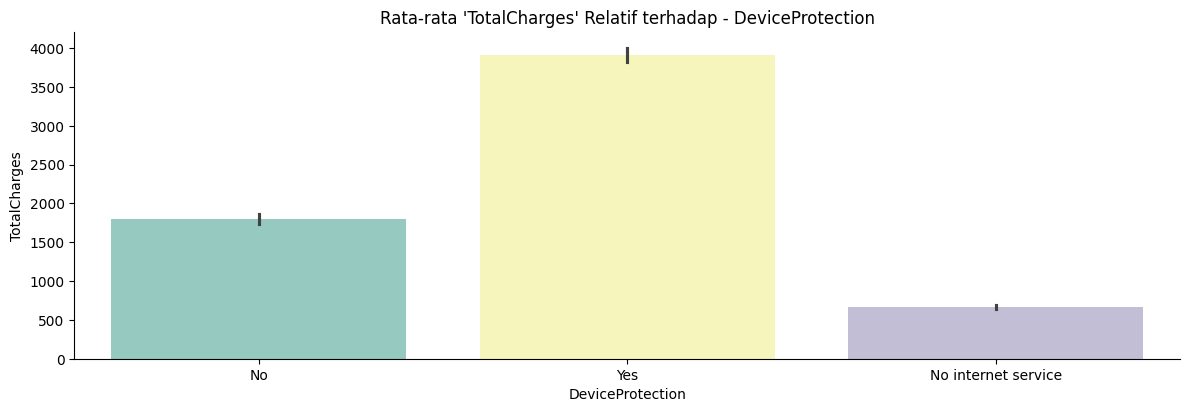

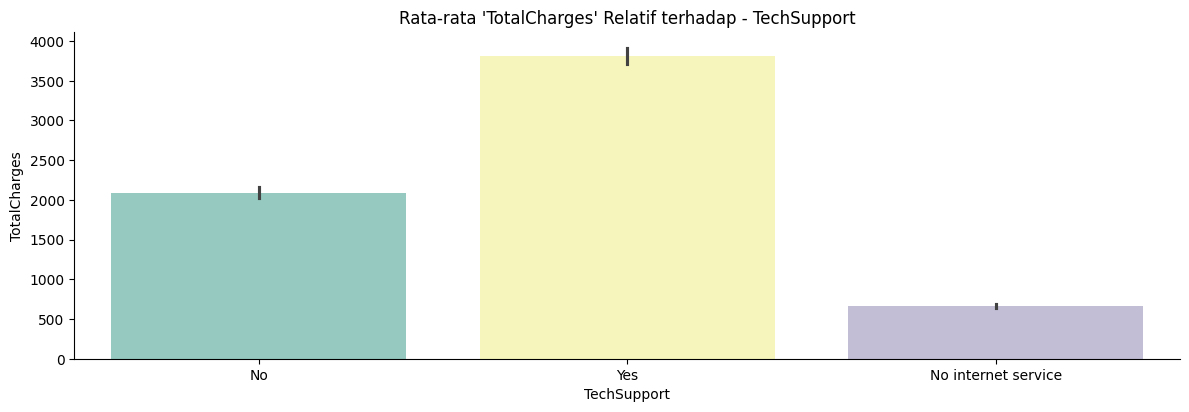

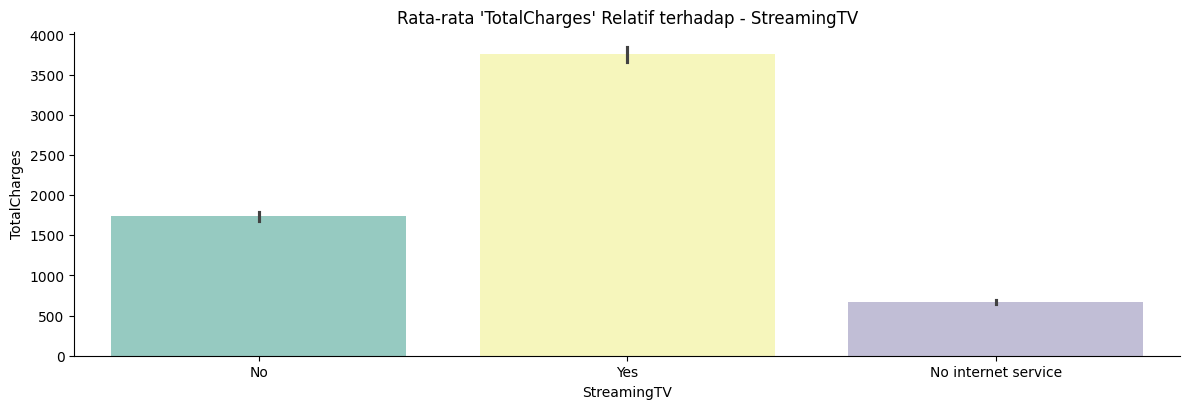

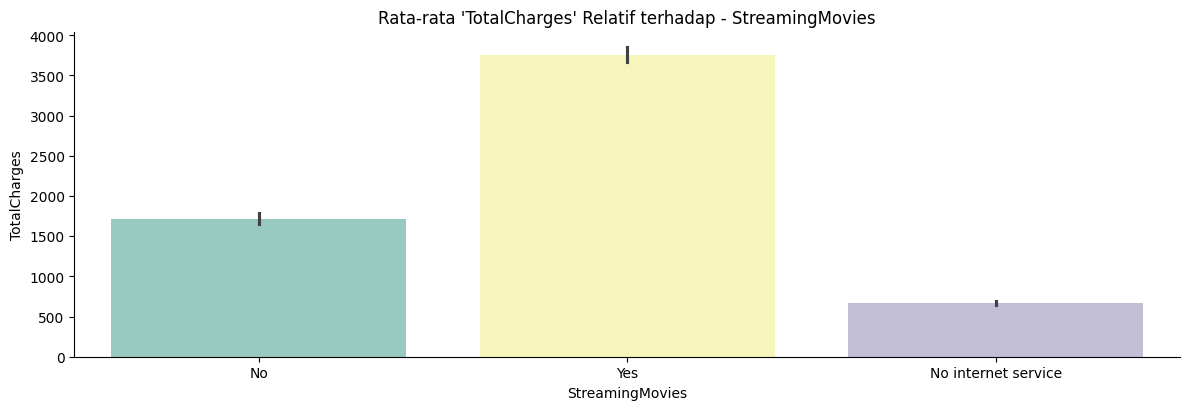

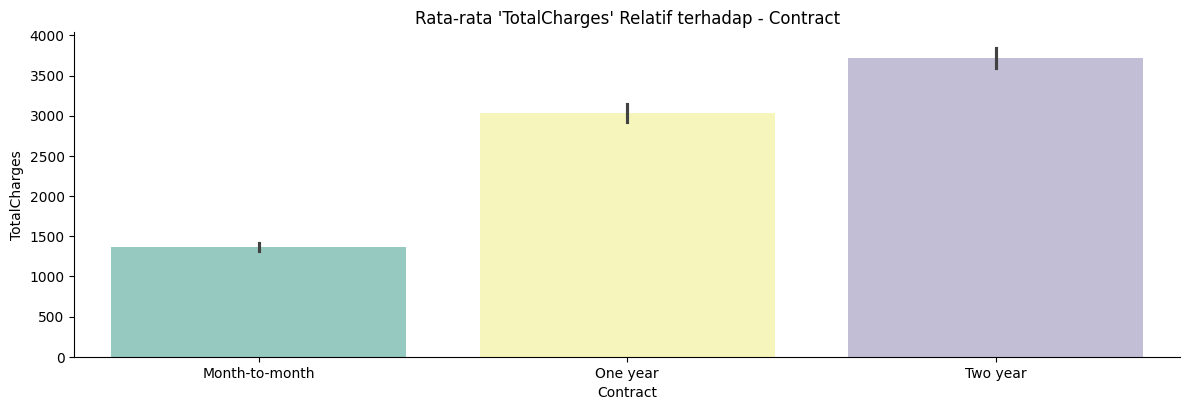

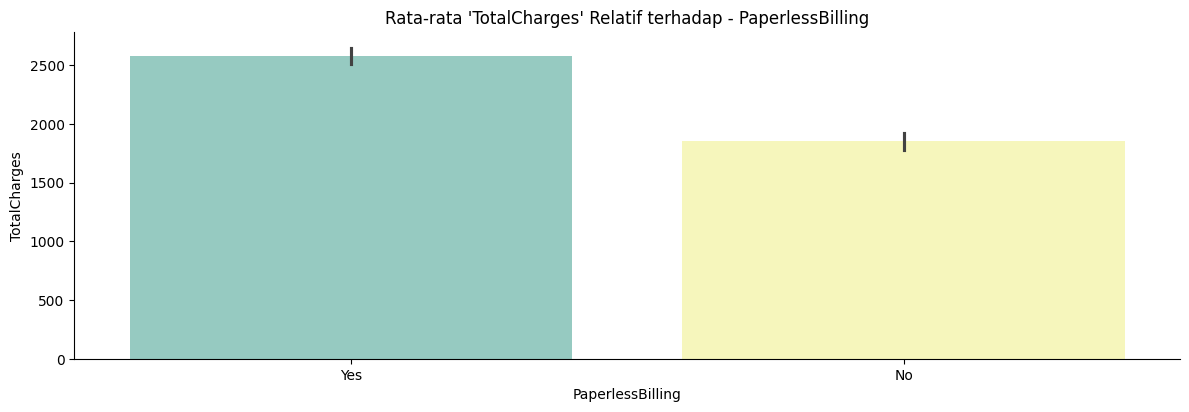

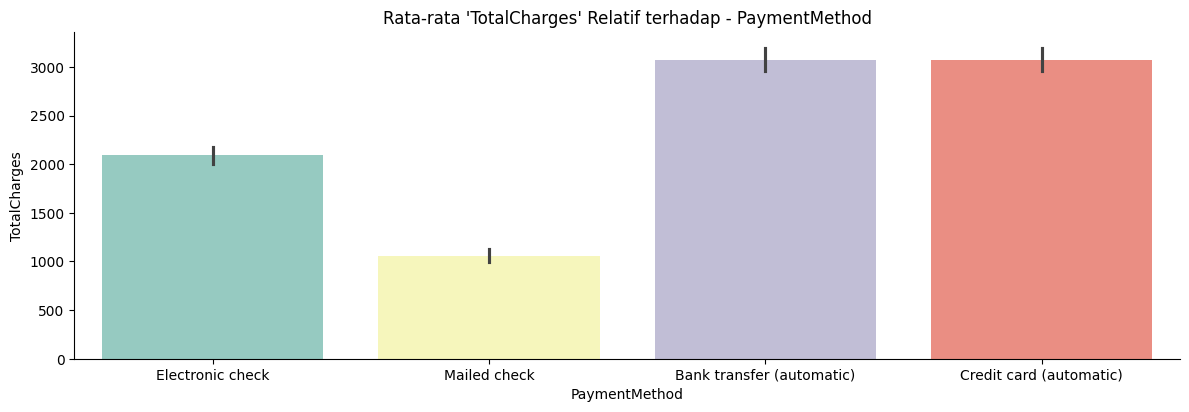

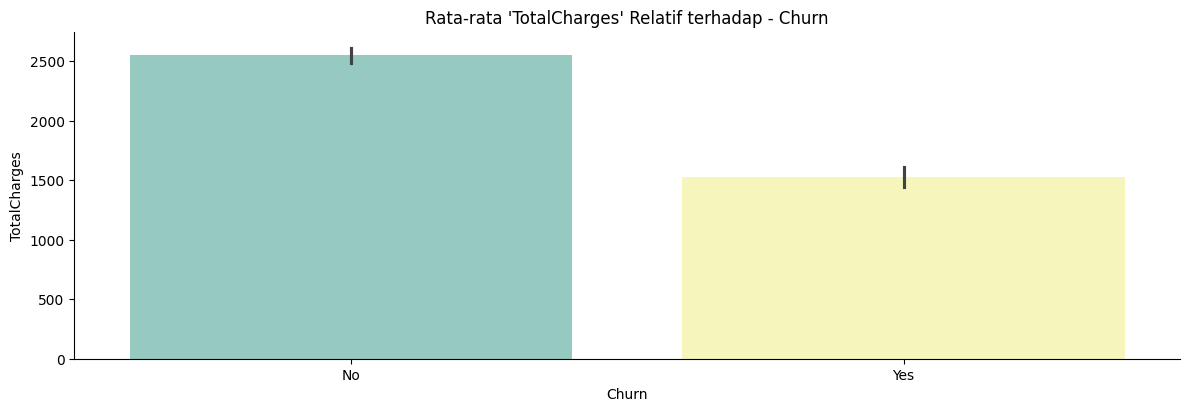

In [ ]:
cat_features = data.select_dtypes(include='object').columns.to_list()

for col in cat_features:
  sns.catplot(x=col, y="TotalCharges", kind="bar", dodge=False, height = 4, aspect = 3,  data=data, palette="Set3")
  plt.title("Rata-rata 'TotalCharges' Relatif terhadap - {}".format(col))

Bagian ini menunjukkan bagaimana kita dapat menangani fitur kategorikal untuk analisis lebih lanjut. Biasanya, kita akan melakukan Label Encoding atau One-Hot Encoding pada fitur kategorikal untuk mengonversinya menjadi format numerik yang bisa diproses oleh model.

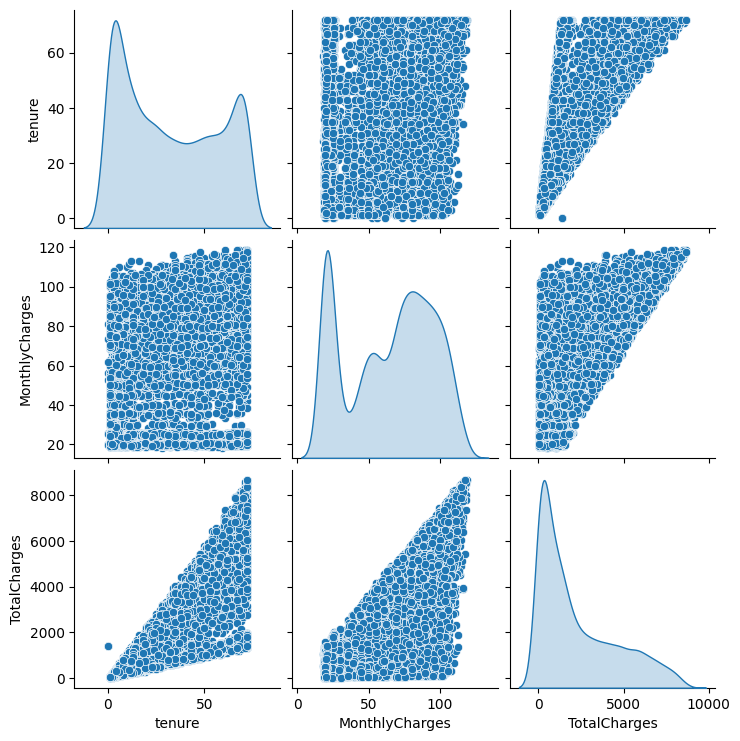

In [ ]:
# Mengamati hubungan antar fitur numerik dengan fungsi pairplot()
sns.pairplot(data, diag_kind = 'kde')

Pada visualisasi ini, pairplot digunakan untuk menampilkan hubungan antar fitur numerik: tenure, MonthlyCharges, dan TotalCharges. Pairplot ini memberikan informasi tentang distribusi masing-masing fitur dan korelasi antar fitur dalam bentuk scatter plot dan plot distribusi (dengan jenis kde untuk diagonal).

*   Hubungan tenure dan TotalCharges menunjukkan bahwa pelanggan yang berlangganan lebih lama membayar lebih banyak secara total.
*   Distribusi biaya bulanan (MonthlyCharges) sebagian besar terpusat pada nilai menengah, dengan sedikit pelanggan yang membayar biaya yang sangat tinggi.
*   Tidak ada korelasi yang sangat kuat antara tenure dan MonthlyCharges, menunjukkan bahwa pelanggan yang membayar lebih rendah atau lebih tinggi tidak selalu memiliki masa berlangganan yang panjang atau pendek.





Text(0.5, 1.0, 'Correlation Matrix untuk Fitur Numerik ')

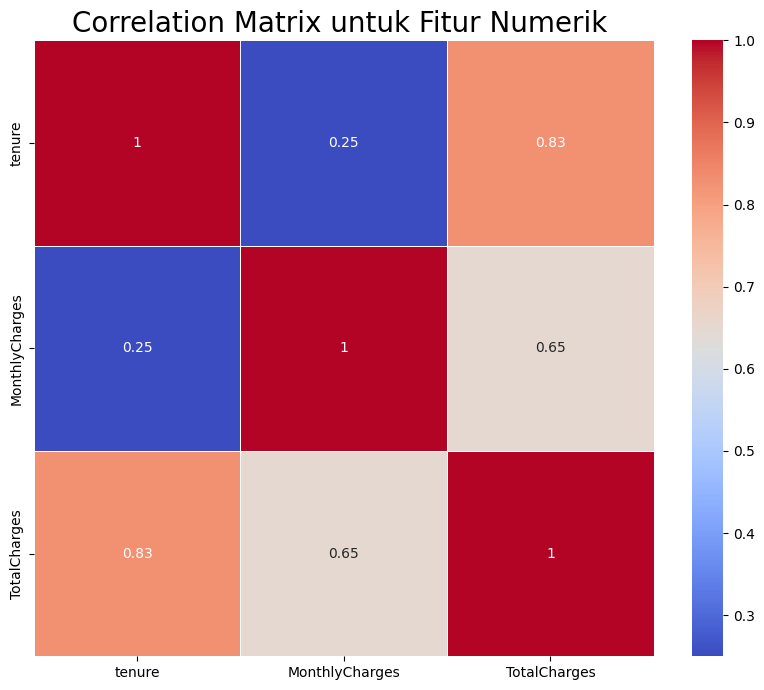

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = data[numerical_features].corr().round(2)

# Untuk menge-print nilai di dalam kotak, gunakan parameter anot=True
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, )
plt.title("Correlation Matrix untuk Fitur Numerik ", size=20)

Pada visualisasi ini, kita menggunakan Matriks Korelasi untuk menunjukkan hubungan antar fitur numerik: tenure, MonthlyCharges, dan TotalCharges. Matriks korelasi mengukur sejauh mana dua fitur berhubungan satu sama lain, dengan nilai berkisar antara -1 (hubungan negatif sempurna) hingga +1 (hubungan positif sempurna).

*   Hubungan yang paling kuat terlihat antara tenure dan TotalCharges (0.83), yang berarti bahwa pelanggan yang berlangganan lebih lama cenderung memiliki total biaya yang lebih tinggi.
*   Hubungan antara MonthlyCharges dan TotalCharges juga cukup signifikan (0.65), mengindikasikan bahwa pelanggan yang membayar lebih banyak setiap bulan biasanya juga memiliki total biaya yang lebih tinggi.



# **5. Data Preprocessing**

In [ ]:
label_encoders = {}
categorical_cols = data.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

Pada tahap ini, kita menggunakan Label Encoding untuk mengonversi fitur kategorikal menjadi angka. Proses ini diperlukan agar algoritma machine learning dapat memproses data numerik.

In [ ]:
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print(f'Total # of sample in whole dataset: {len(X)}')
print(f'Total # of sample in train dataset: {len(X_train)}')
print(f'Total # of sample in test dataset: {len(X_test)}')

Total # of sample in whole dataset: 7043
Total # of sample in train dataset: 5634
Total # of sample in test dataset: 1409


Kita membagi dataset menjadi dua bagian: data latih (80%) dan data uji (20%). Data latih digunakan untuk melatih model, sementara data uji digunakan untuk mengevaluasi kinerja model setelah pelatihan.

In [ ]:
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

Standardisasi dilakukan untuk menormalkan fitur numerik seperti tenure, MonthlyCharges, dan TotalCharges, yang penting untuk model seperti KNN atau Logistic Regression. Meskipun Decision Tree dan Random Forest tidak sensitif terhadap skala, ini adalah langkah yang baik untuk memastikan model lainnya dapat bekerja dengan baik.

# **6. Melatih dan Mengevaluasi Model**

In [ ]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1036
           1       0.48      0.51      0.50       373

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.73      0.73      1409



Decision Tree:

Lebih efektif dalam mendeteksi kelas 0 (recall tinggi), tetapi memiliki precision rendah untuk kelas 1, yang menyebabkan banyak kesalahan dalam mengklasifikasikan kelas 1. Akurasi keseluruhan juga lebih rendah dibandingkan dengan Random Forest.

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Random Forest:

Memiliki kinerja yang lebih seimbang secara keseluruhan, terutama dengan precision yang lebih tinggi untuk kelas 1 dan recall yang sangat baik untuk kelas 0. Meskipun ada sedikit kekurangan dalam mendeteksi kelas 1 (recall lebih rendah), Random Forest memiliki akurasi lebih tinggi dan performa yang lebih baik secara keseluruhan.

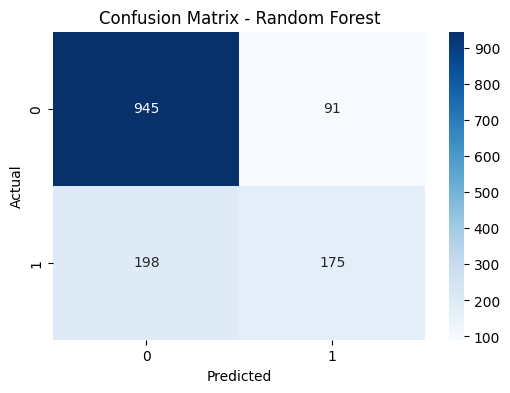

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Model Random Forest memiliki akurasi yang baik, namun masih perlu perbaikan pada deteksi kelas 1, terlihat dari tingginya jumlah False Negatives (198), yang menunjukkan banyak data kelas 1 yang tidak terdeteksi dengan benar. Model ini cenderung lebih baik dalam mengklasifikasikan kelas 0, tetapi False Positives (91) dan False Negatives (198) menunjukkan adanya trade-off antara precision dan recall yang perlu ditingkatkan.

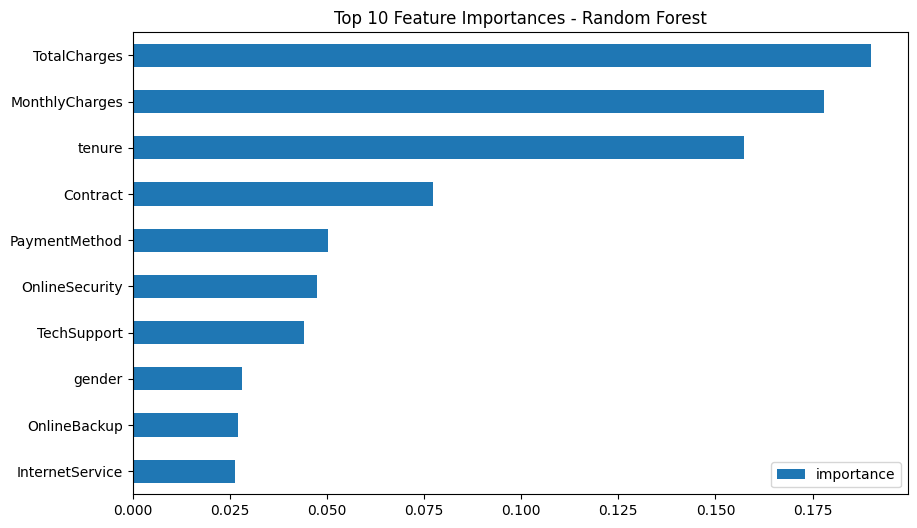

In [ ]:
feature_importances = pd.DataFrame(rf_model.feature_importances_,
                                   index = X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)


feature_importances.head(10).plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.show()

Dari grafik feature importance yang ditampilkan, kita dapat melihat perbandingan kepentingan fitur-fitur dalam model Random Forest yang digunakan untuk prediksi.

*   TotalCharges memiliki feature importance tertinggi, menunjukkan bahwa ini adalah fitur yang paling mempengaruhi keputusan model dalam klasifikasi.
*   MonthlyCharges dan tenure juga memiliki nilai feature importance yang signifikan, yang berarti kedua fitur ini memberikan kontribusi besar dalam memprediksi output model.
*   Contract, PaymentMethod, dan OnlineSecurity juga penting, meskipun dengan nilai yang lebih rendah dibandingkan tiga fitur pertama.
*   Fitur seperti gender, OnlineBackup, dan InternetService memiliki importance lebih rendah, yang menunjukkan bahwa fitur-fitur ini tidak memberikan kontribusi yang signifikan dalam keputusan model.



